In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

import cmcrameri.cm as cmc

from geoscripts.dz import dz,mda

from matplotlib import rc
rc("pdf", fonttype=42)

In [10]:
path = 'laserchron_data/VanTongeren_MR24_compiled geochron.xlsx'
sheets = ['MR24-10','MR24-12','MR24-13','MR24-15','MR24-16']

In [11]:
data = []
for sheet in sheets:
    accepted = pd.read_excel(path,skiprows=22,header=None,index_col=0,usecols='A:T',
                             sheet_name=sheet)
    
    cols_combined = accepted.iloc[0] + ' ' + accepted.iloc[1]
    accepted.columns = cols_combined
    accepted.drop(accepted.index[:3],inplace=True)

    accepted = accepted[accepted.index.str.contains(sheet)]
    name = sheet[:5] + sheet[5:].zfill(3)
    print(name)

    data.append((accepted,name))

MR24-010
MR24-012
MR24-013
MR24-015
MR24-016


In [12]:
# Get location data from field notes
meta_mr = pd.read_csv('field_data/2024_mr_field_samples.csv',index_col=0)
locations = meta_mr[['Latitude','Longitude']]

Propagating systematic error -  0.8 
Original error:  3.4


/home/dyvasey/git/geoscripts/geoscripts/dz/dz.py:628: RuntimeWarning: invalid value encountered in scalar divide
  self.mda_mswd = squares_summed/deg_free


Propagating systematic error -  0.8 
Original error:  1.552286202620107
Propagating systematic error -  0.8 
Original error:  1.4661910754012286
Propagating systematic error -  0.8 
Original error:  4.089675099211381
Propagating systematic error -  0.8 
Original error:  1.4202418003470958


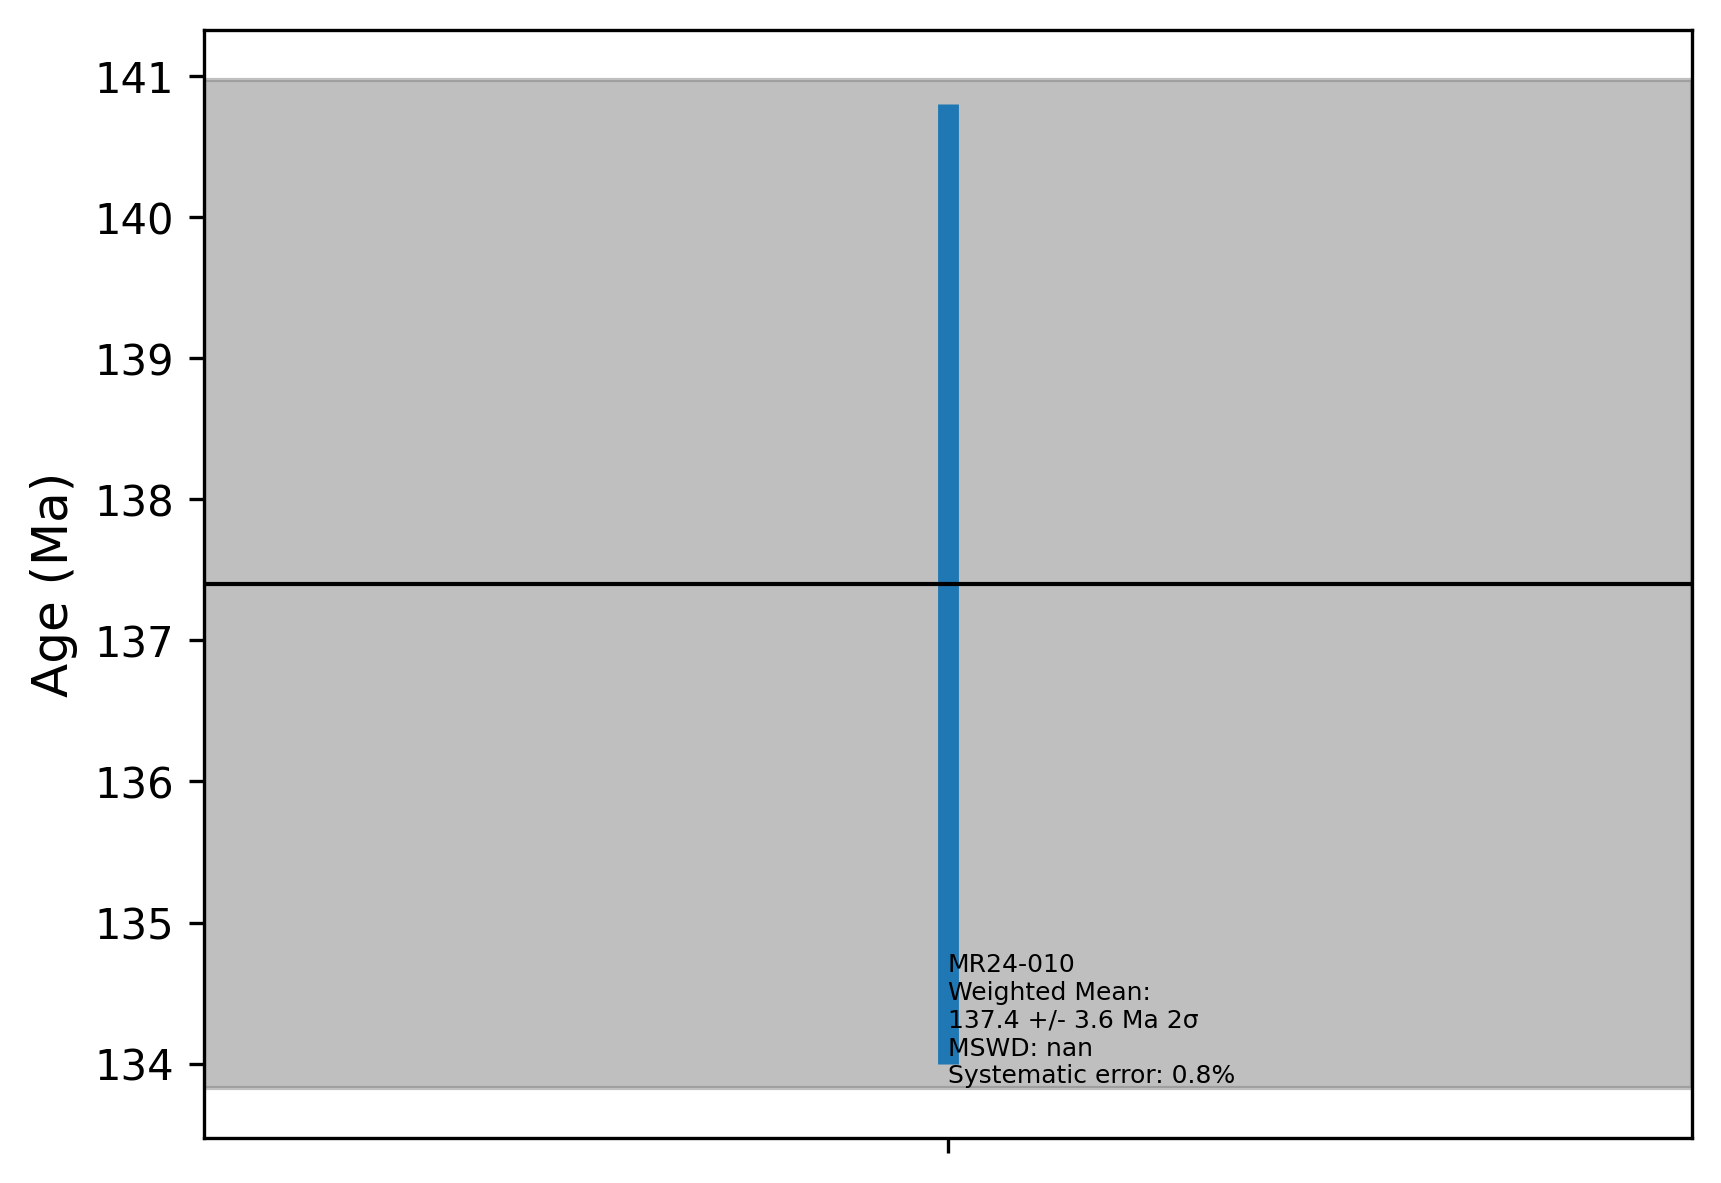

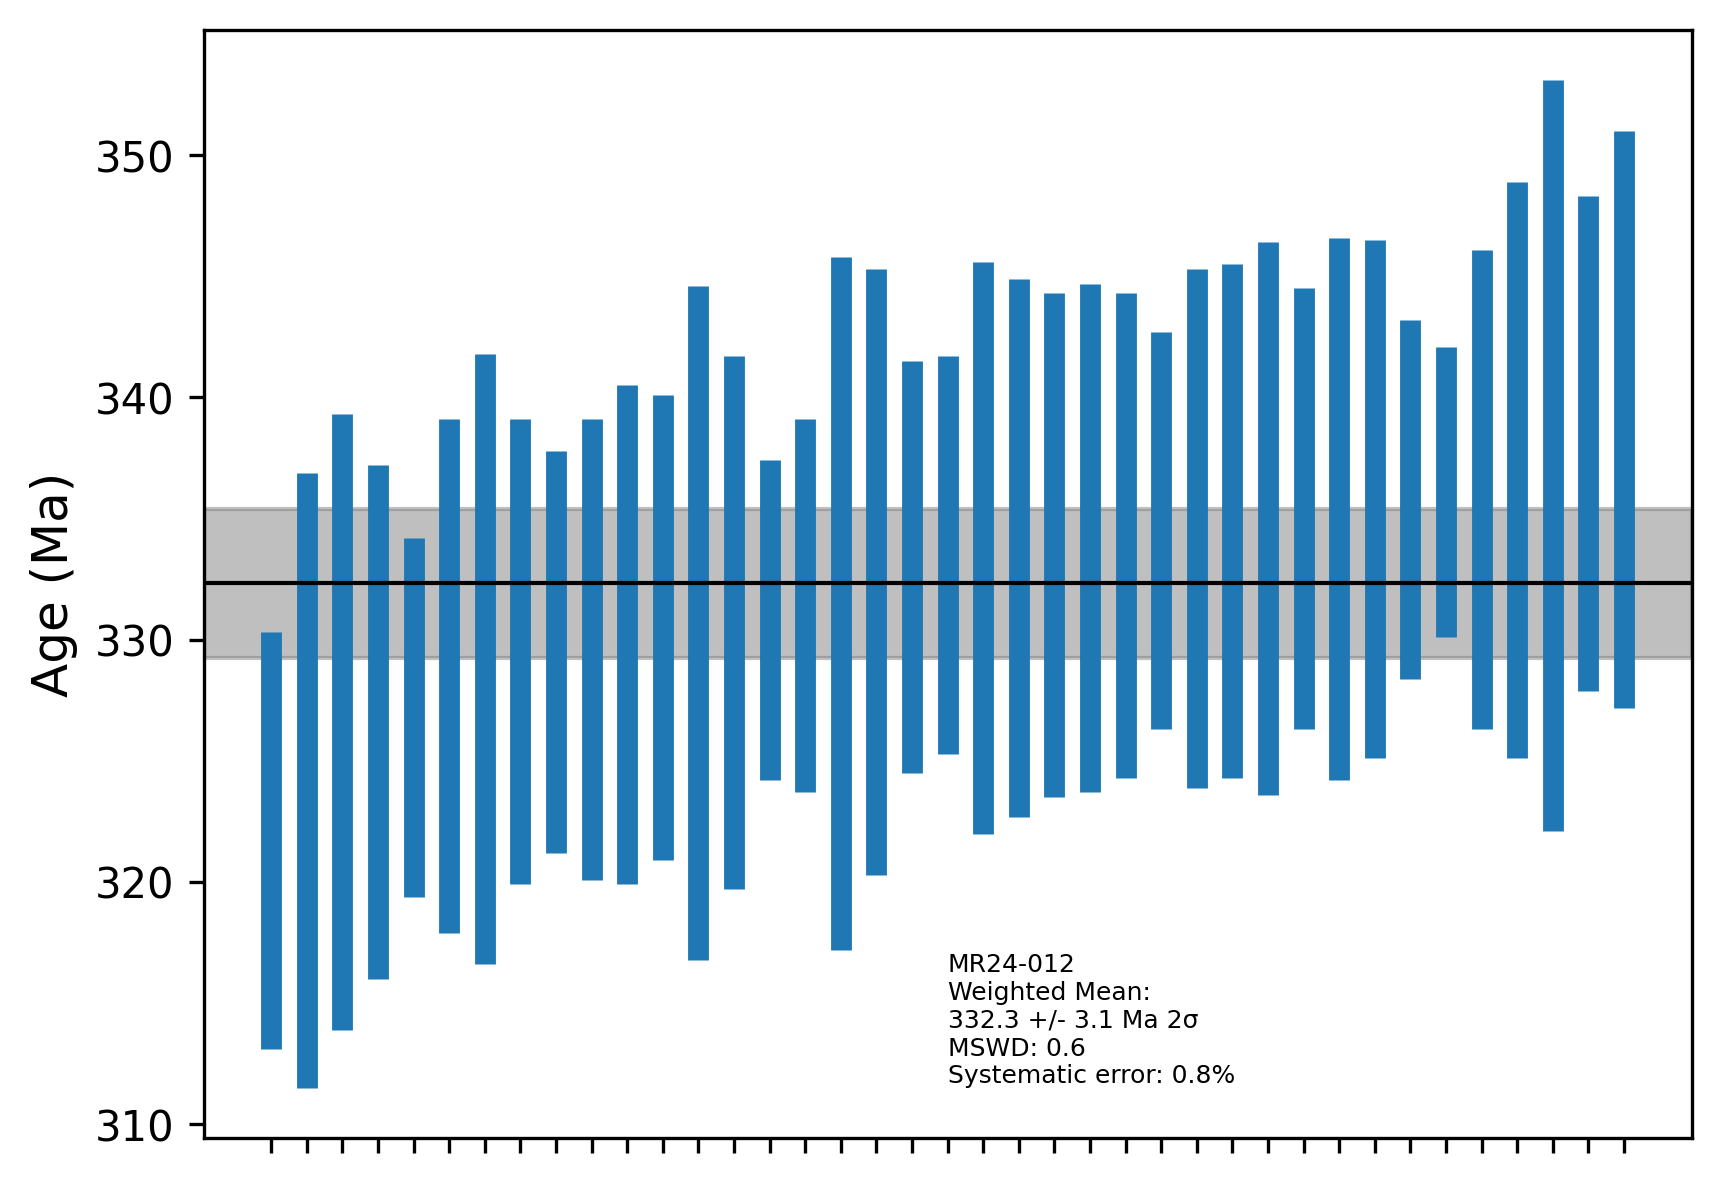

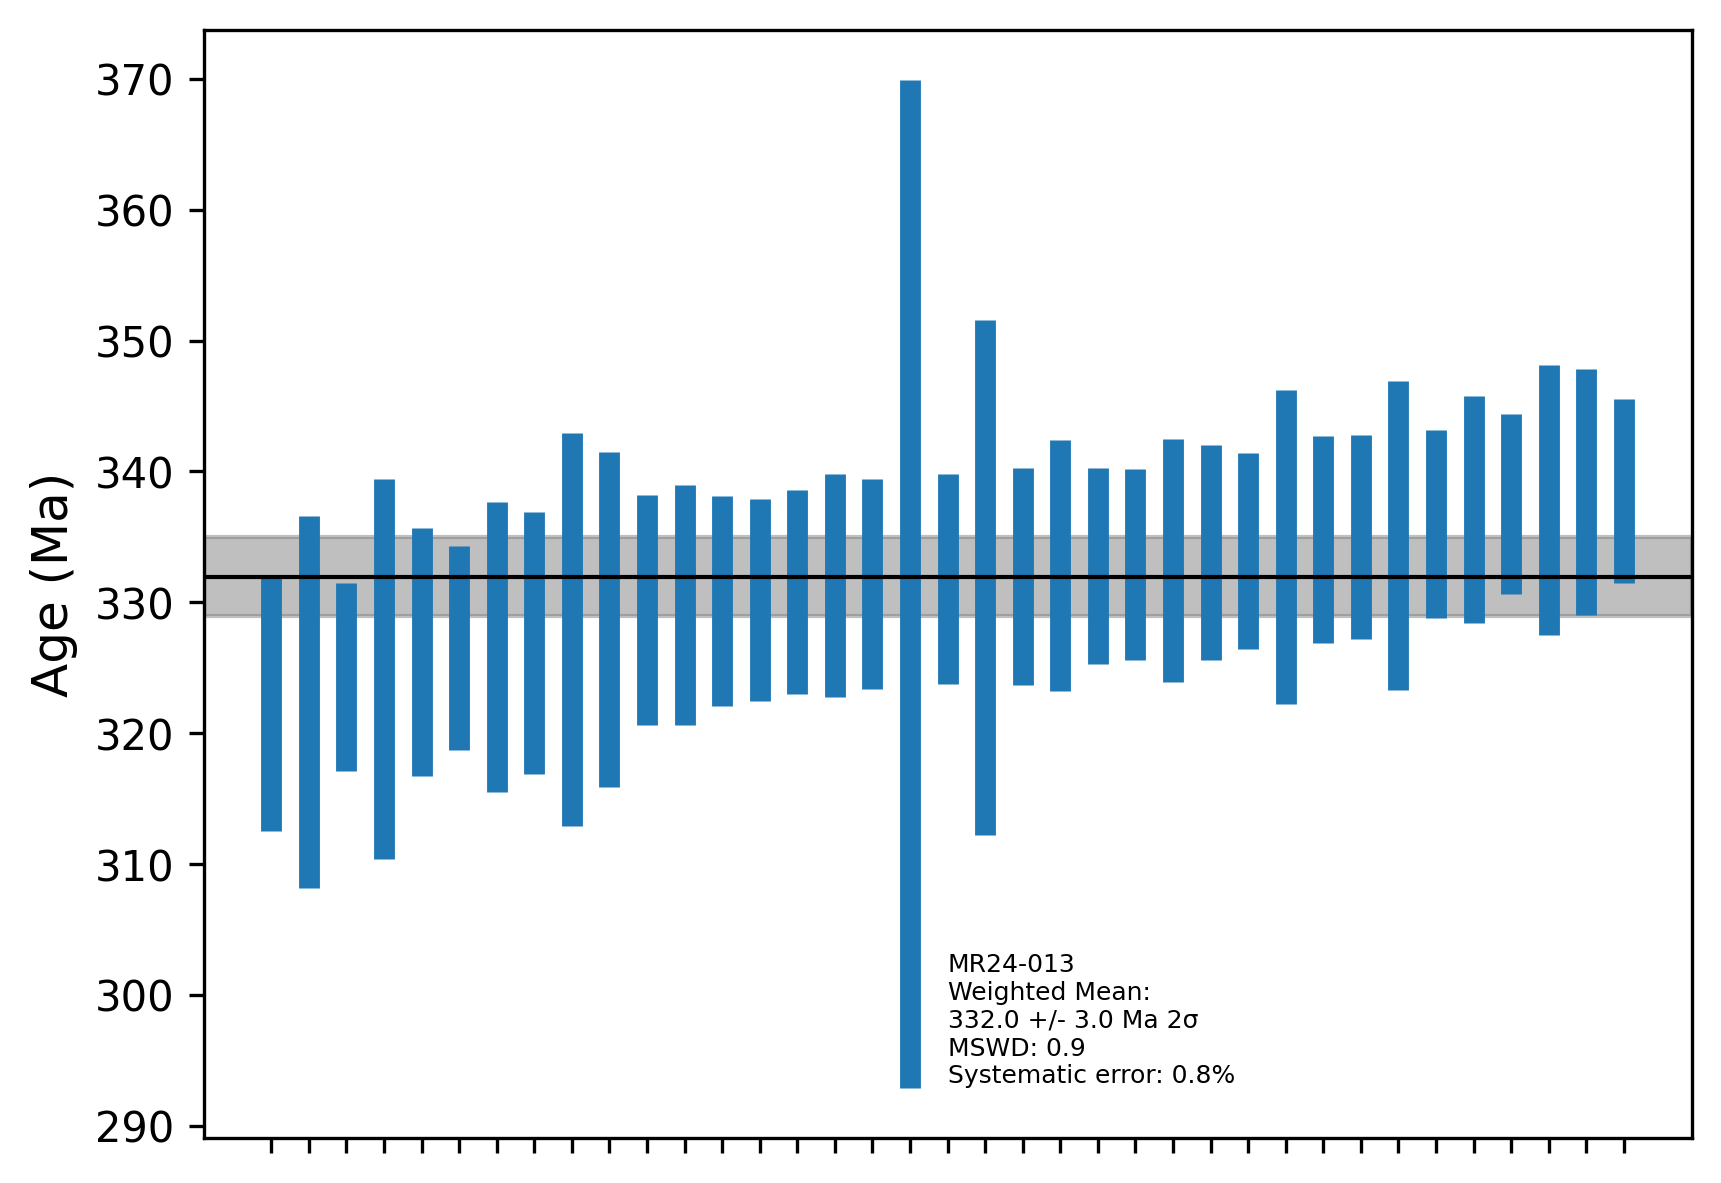

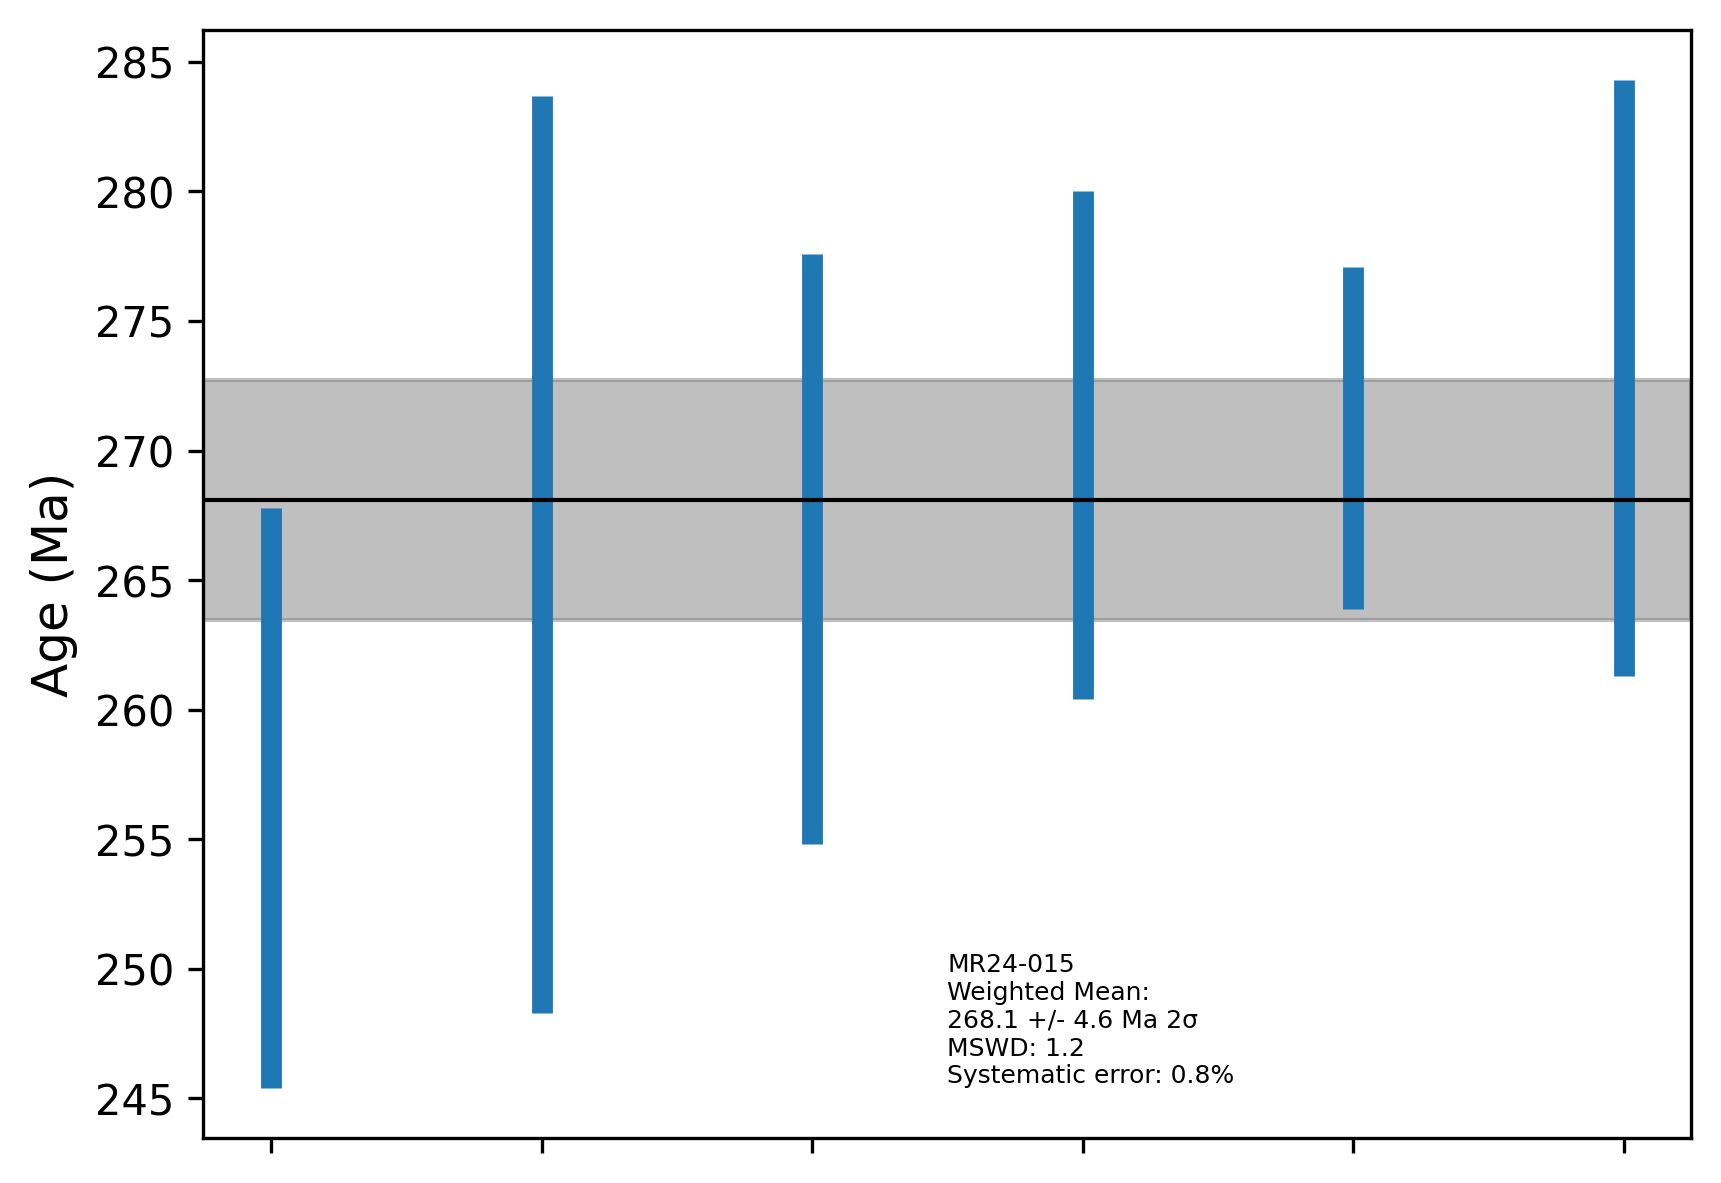

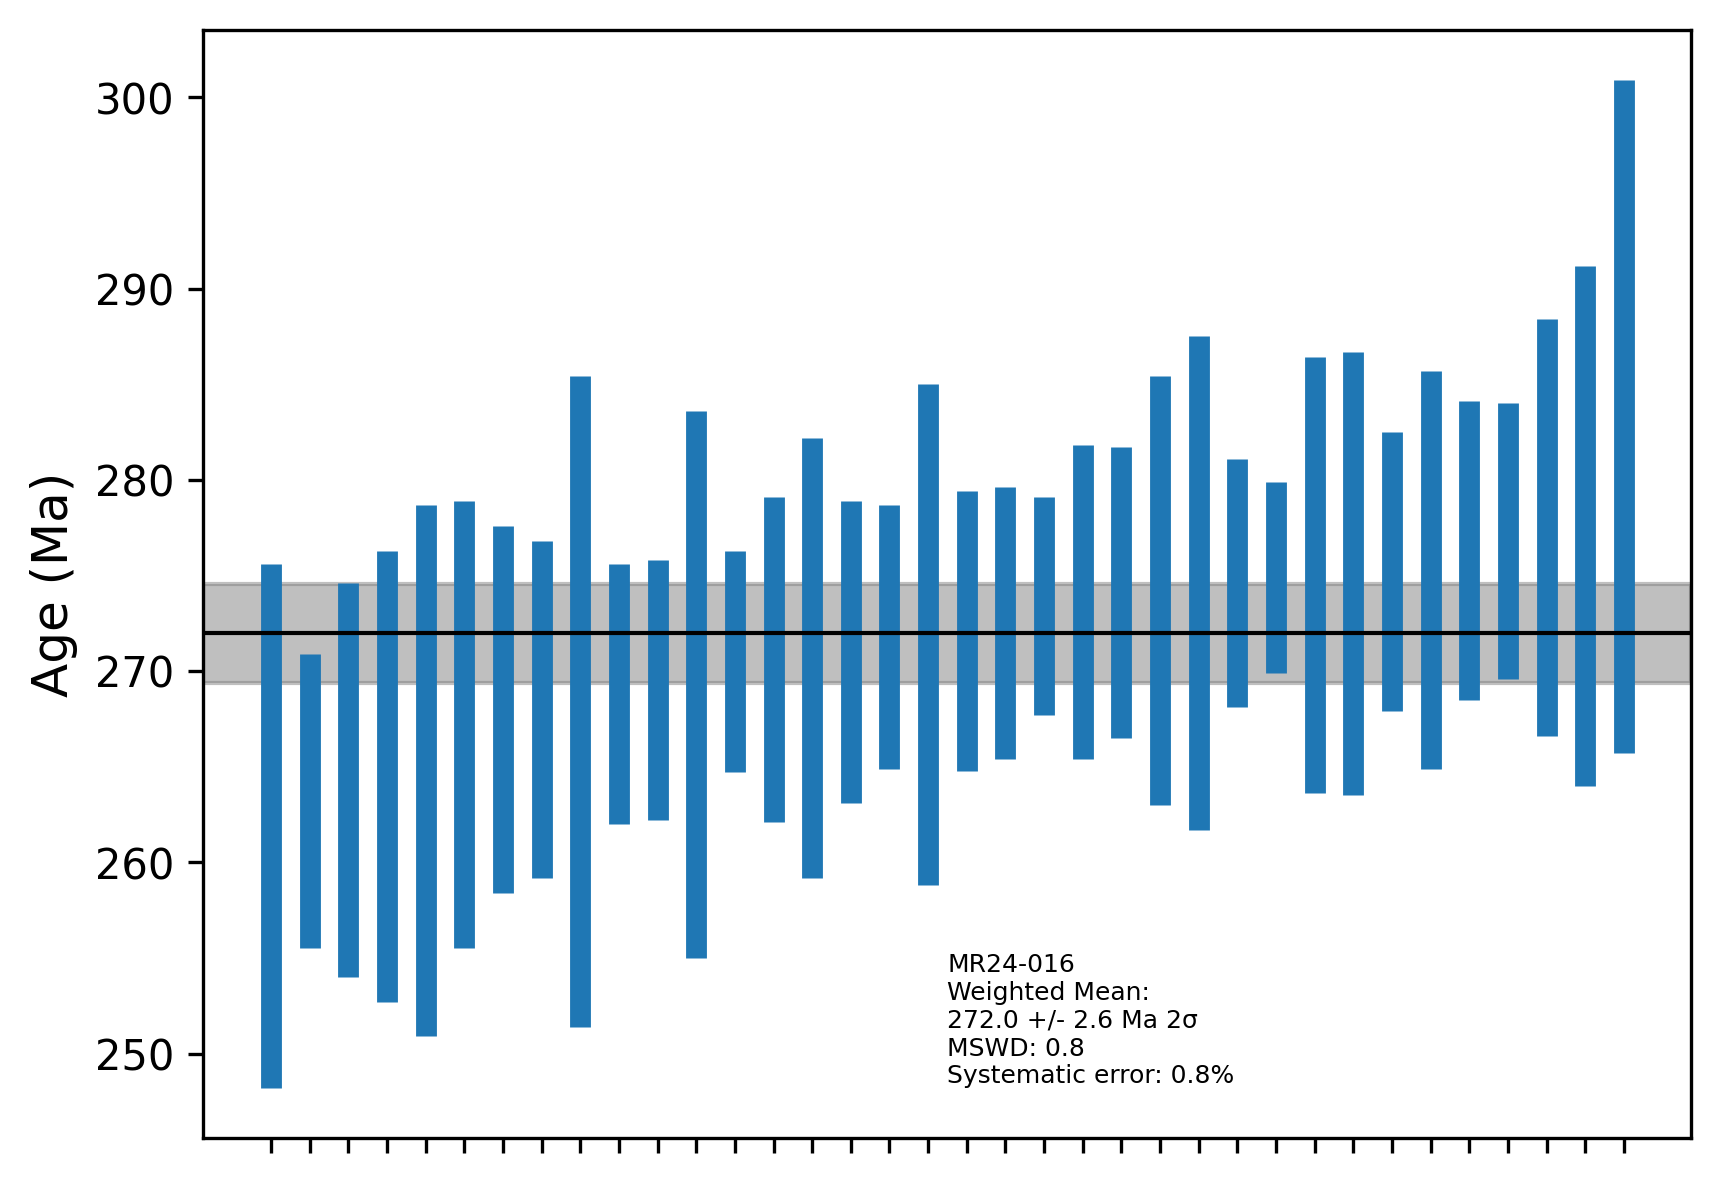

In [13]:
# Create DZ objects from data
smps = [dz.DZSample(name=sample[1],agedata=sample[0],
                    latlon=(locations.loc[sample[1],'Latitude'],
                            locations.loc[sample[1],'Longitude']),
                            source='VanTongeren',reported_age='P-Tr') for sample in data]
smps.sort(key=lambda x: x.name)

for smp in smps:
    smp.bestage = smp.agedata['Best age (Ma)'].astype(float)
    smp.bestage.name = 'Best Age'
    smp.besterror = smp.agedata.iloc[:,-2].astype(float)
    smp.besterror.name = '2sig'
    smp.error_level = '2sig'
    smp.syst_238=0.8

    if smp.name=='MR24-010':
        smp.calc_mda(method='manual',grains=[0],systematic=True)

    else:
        smp.calc_mda(systematic=True)
    smp.save()

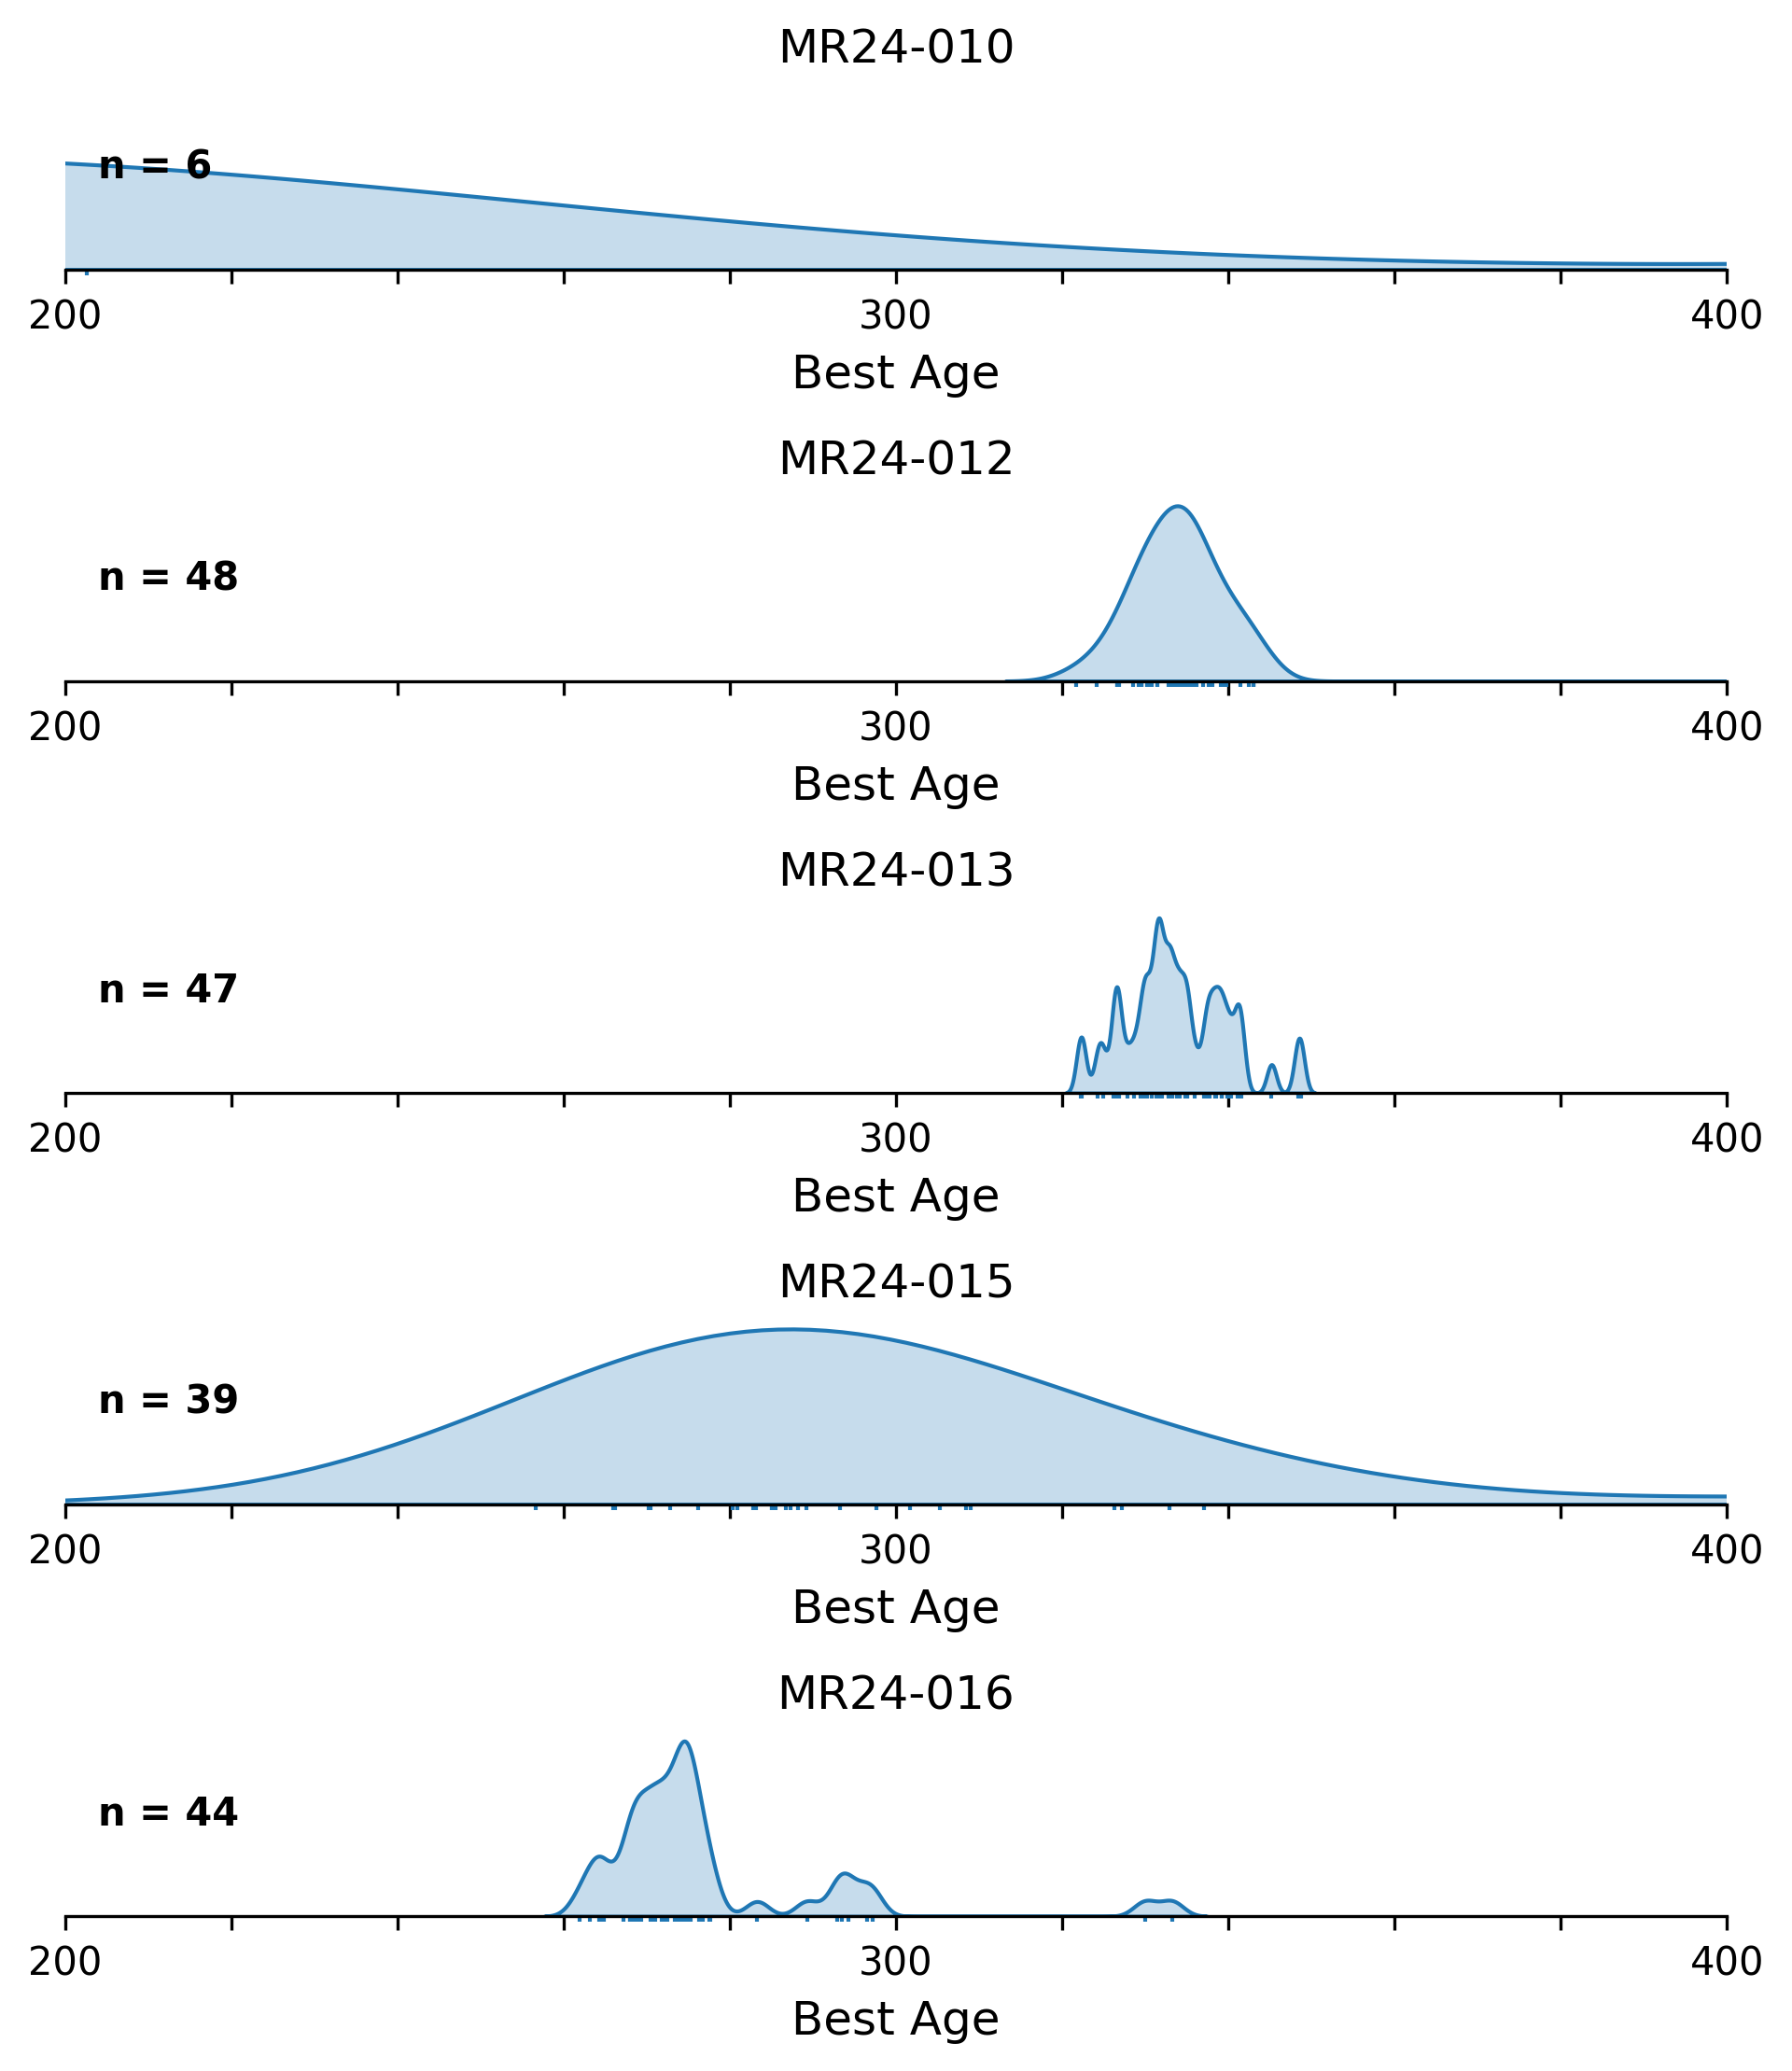

In [14]:
# Plot KDEs using existing best ages (not calculated)
fig,axs = plt.subplots(len(smps),figsize=(6.5,1.5*len(smps)),dpi=300)

for k,smp in enumerate(smps):
    ax = axs[k]
    smp.kde(ax=ax,bw_adjust=0.2,log_scale=False)
    ax.set_xlim(200,400)
    ax.set_title(smp.name)
    ax.set_xticks(np.arange(200,401,20))

plt.tight_layout()
fig.savefig('kdes_ig.pdf')

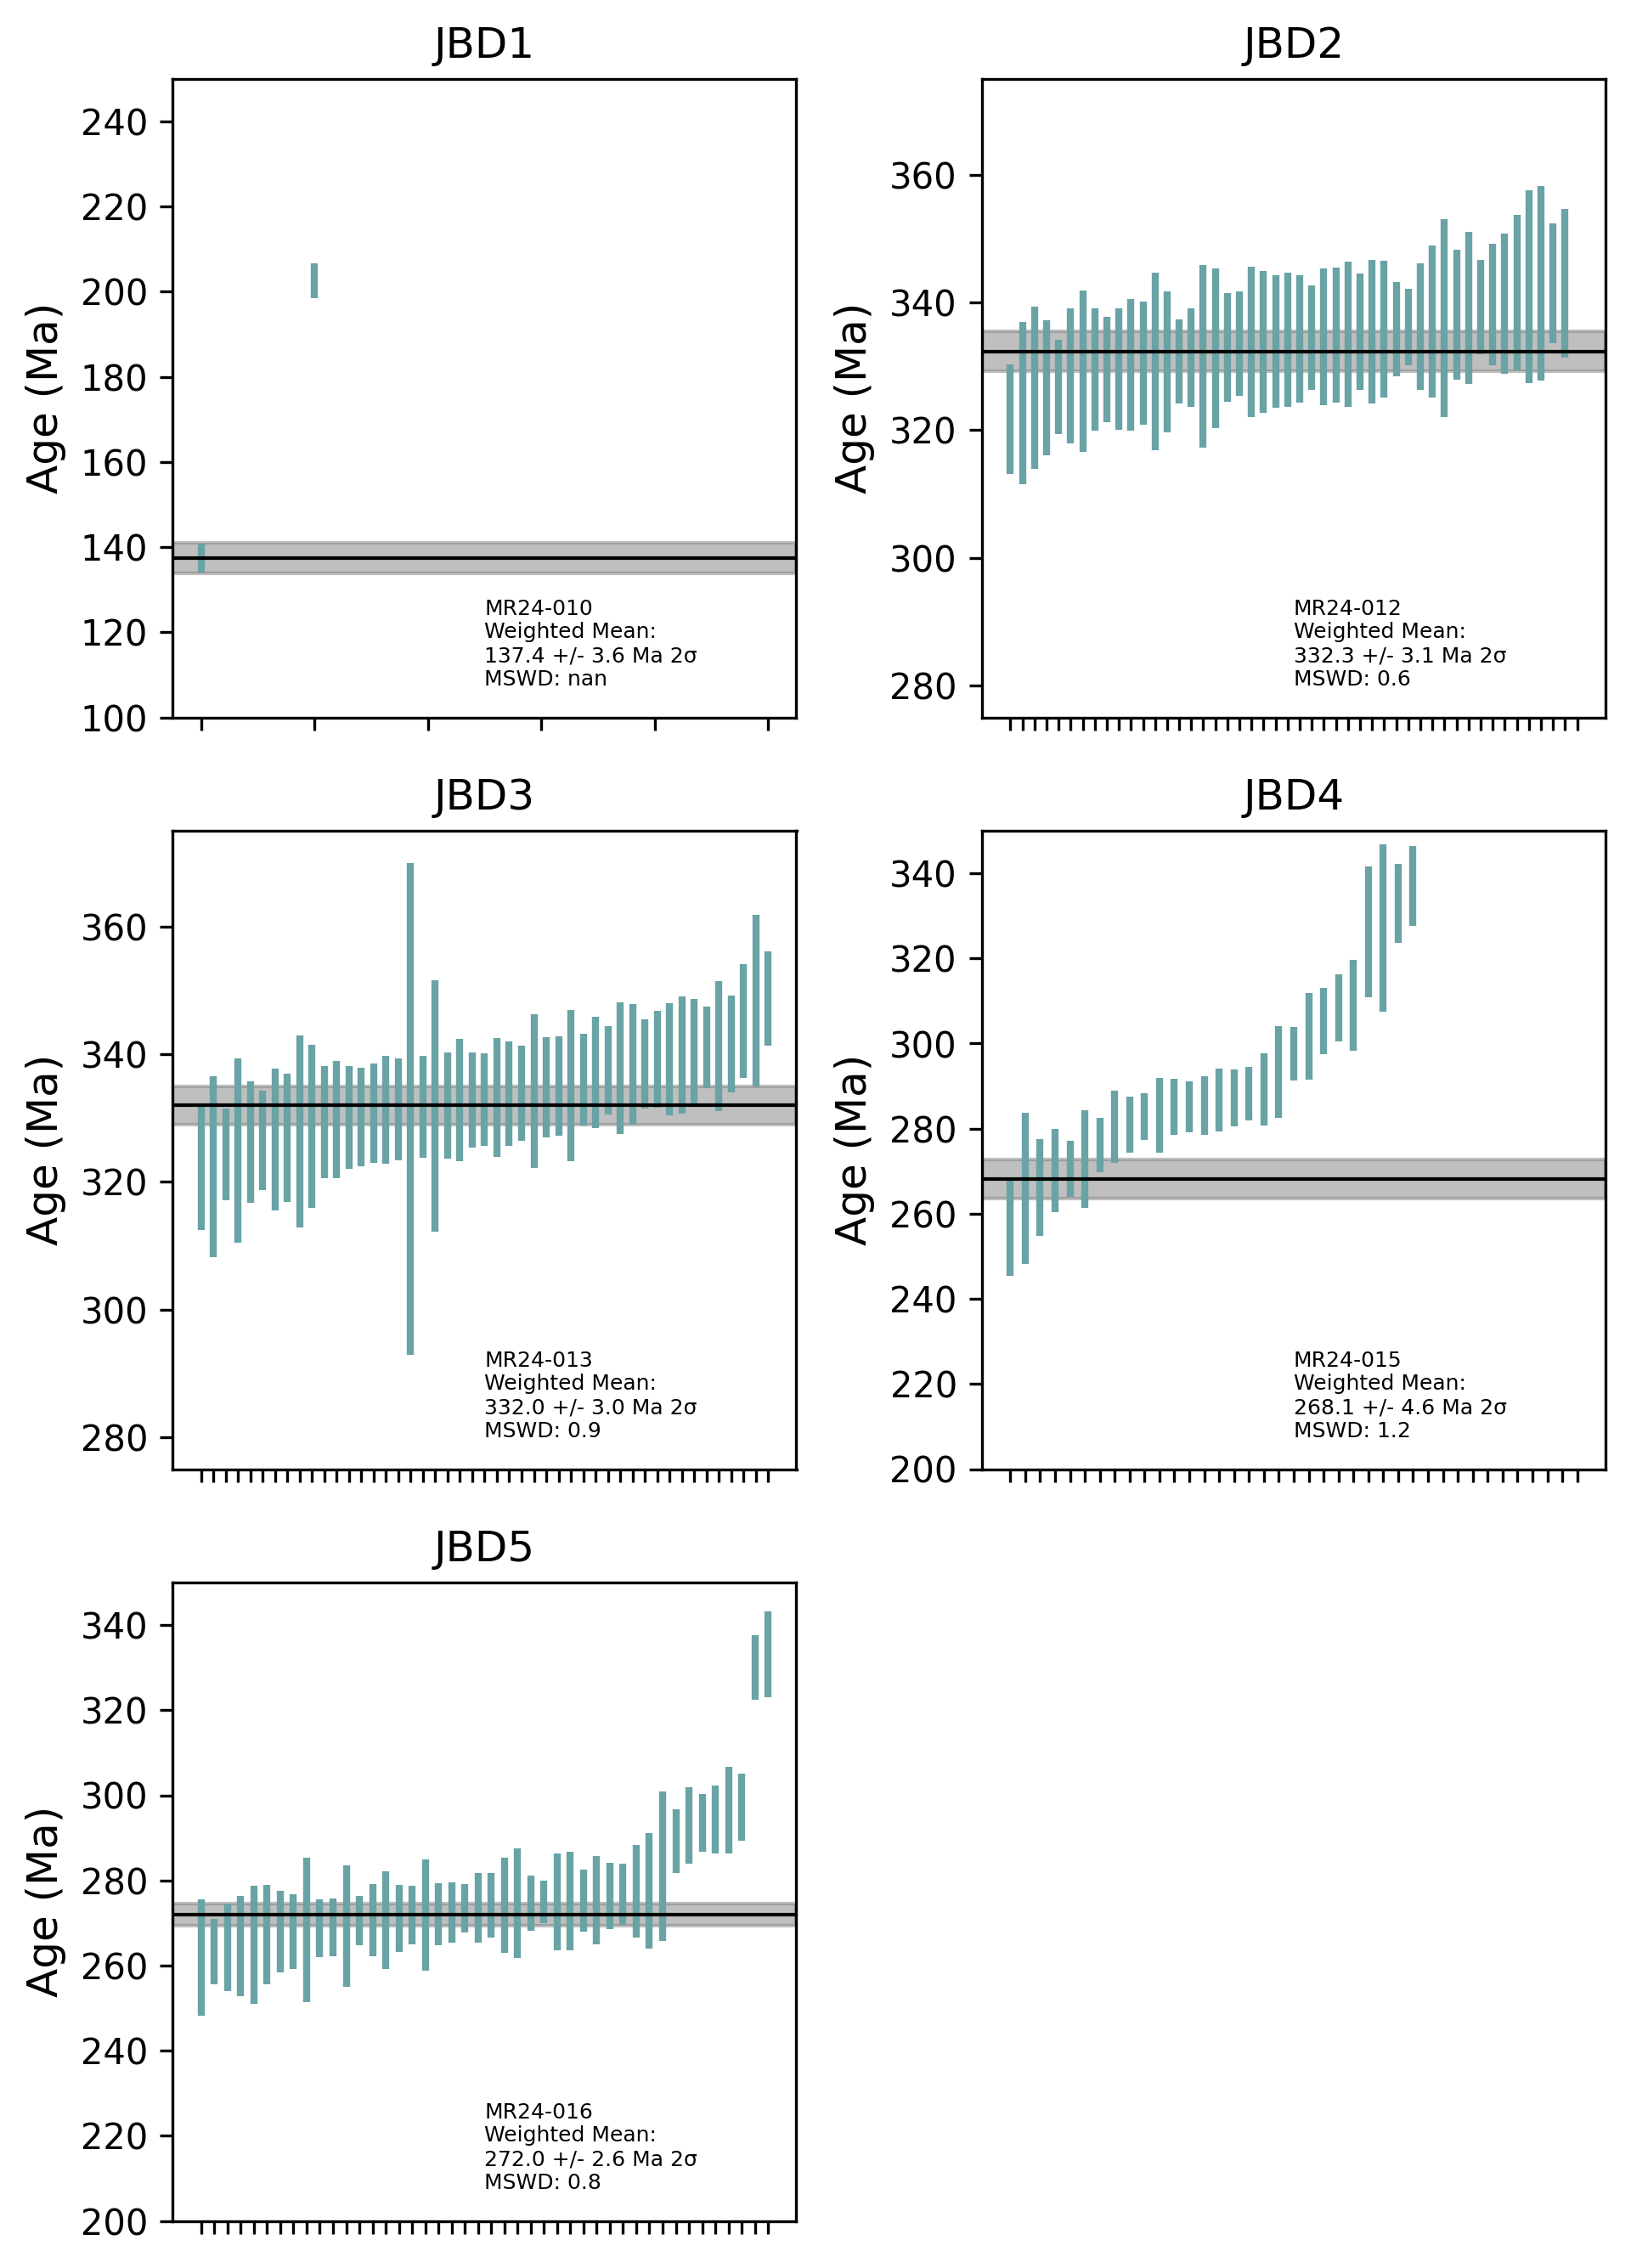

In [15]:
# Make a weighted mean plot showing all ages
fig,axs = plt.subplots(3,2,figsize=(6.5,9),dpi=300)
new_names = ['JBD1','JBD2','JBD3','JBD4','JBD5']
lim_dict = {'JBD1':(100,250),'JBD2':(275,375),'JBD3':(275,375),'JBD4':(200,350),
            'JBD5':(200,350)}

for k,ax in enumerate(axs.flat[:-1]):
    smp = smps[k]
    ax.set_title(new_names[k])

    age_df = pd.DataFrame({'Age':smp.bestage,'Error':smp.besterror})
    age_df.sort_values('Age',inplace=True)
    ax.set_ylim(lim_dict[new_names[k]])
    #ax.set_yscale('log')

    mda.plot_weighted_mean(ages=age_df['Age'], errors=age_df['Error'], mean=smp.mda, 
                           mean_error=smp.mda_err, mswd=smp.mda_mswd, ax=ax,
                           err_linewidth=2,annotate_location=(0.5,0.05),
                           color='#69a3a5', label=smp.name)

axs.flat[-1].axis('off')
plt.tight_layout()
fig.savefig('ig_means.pdf')
